# Feature Engineering
### **Mohon membaca setiap instruksi dan tag komentar dengan saksama sebelum melanjutkan pengerjaan.**

In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.model_selection import train_test_split

# Scalling untuk MinMax Scaller
from sklearn.preprocessing import MinMaxScaler
# Set the maximum number of columns and rows to display to a large number
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# B. Outlier Handling

### Outlier Handling : InterQuartile Handling

In [23]:
# untuk plot Q-Q
import scipy.stats as stats

In [24]:
df_california = pd.read_csv('california_dataset.csv')

In [25]:
from sklearn.model_selection import train_test_split
# splitting terlebih dahulu


#NOTES :
#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)
#data train di-handling outliernya
#tapi tidak untuk data test, karena data test ibarat representasi data masa depan yang digunakan untuk melihat performa Machine Learning

### Assignment 1.a :
1. lakukan looping untuk melihat plot distribusi data dan outlier pada kolom-kolom : ['MedInc', 'HouseAge', 'AveRooms','AveBedrms', 'AveOccup'] di california_dataset.csv
2. Daftar nama kolom yang Anda cek, kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

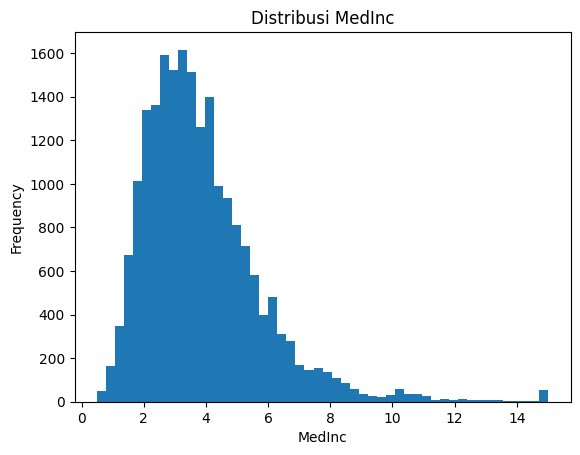

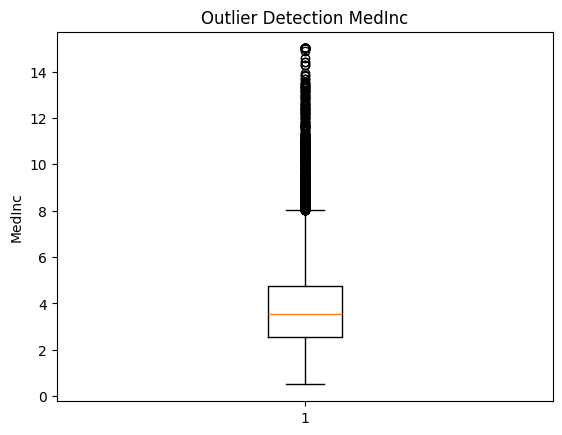

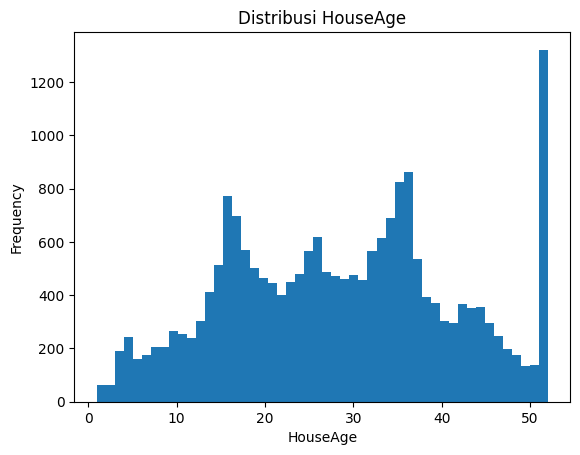

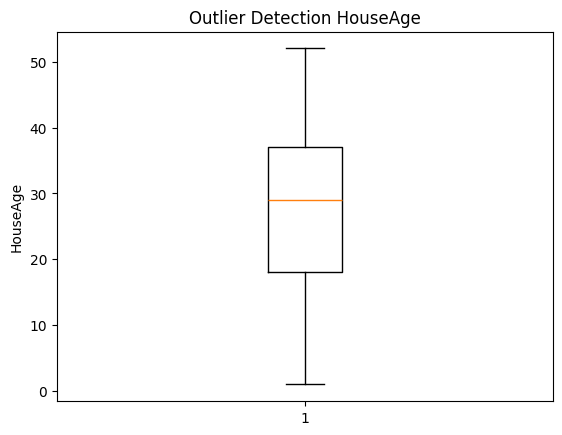

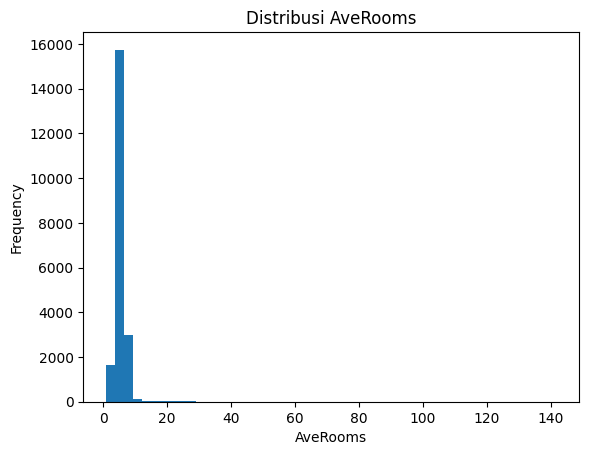

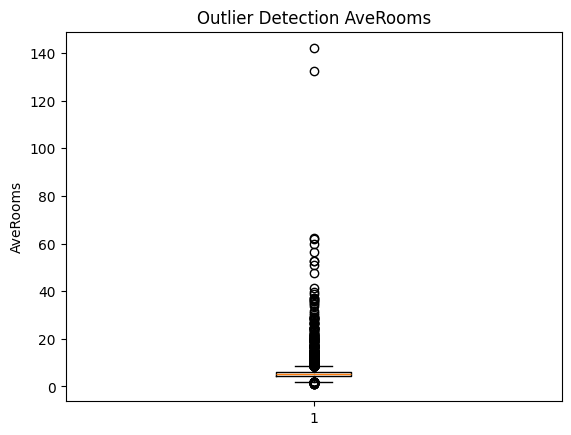

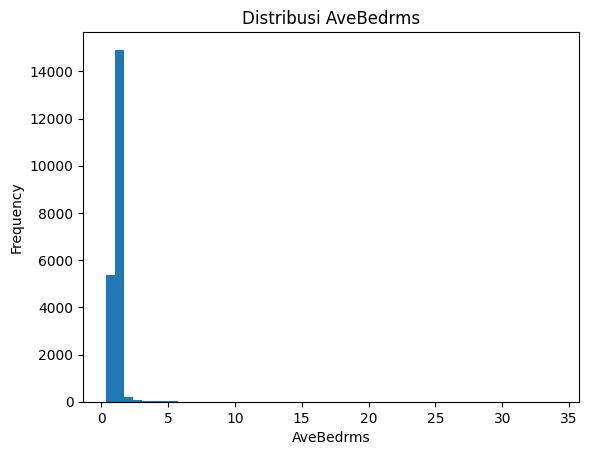

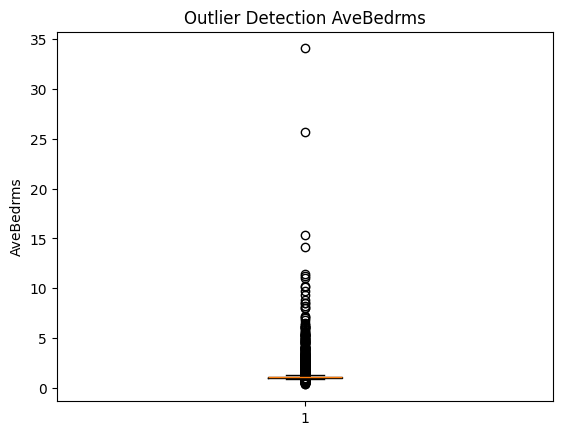

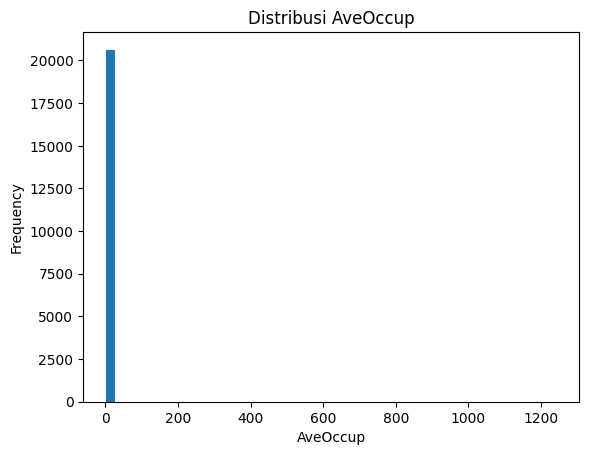

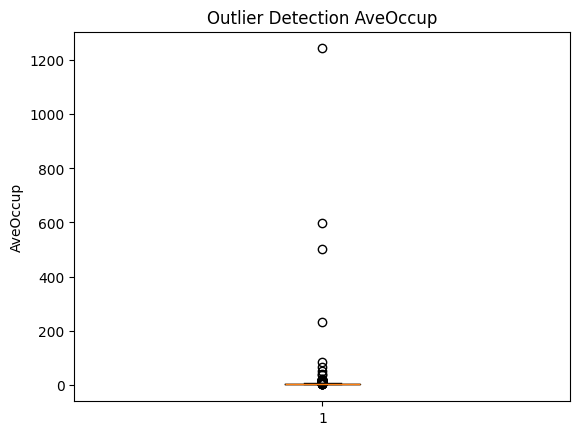

In [26]:
import pandas as pd
import matplotlib.pyplot as plt

# membaca dataset
df = pd.read_csv("california_dataset.csv")

# daftar kolom yang dicek
kolom_kolom = ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'AveOccup']

for kolom in kolom_kolom:
    
    # plot distribusi (Histogram)
    plt.figure()
    plt.hist(df[kolom], bins=50)
    plt.title("Distribusi " + kolom)
    plt.xlabel(kolom)
    plt.ylabel("Frequency")
    plt.show()
    
    # plot outlier (Boxplot)
    plt.figure()
    plt.boxplot(df[kolom])
    plt.title("Outlier Detection " + kolom)
    plt.ylabel(kolom)
    plt.show()

### Assignment 1.b
1. Lakukan handling outlier pilih 1 kolom saja yang di handling dengan IQR setelah mengecek distribusinya
2. Dan cek distribusinya kembali

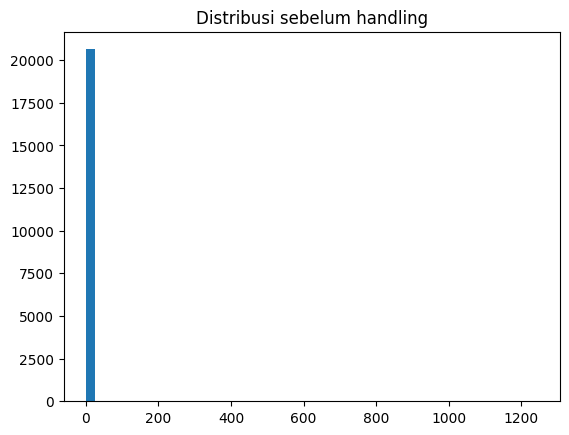

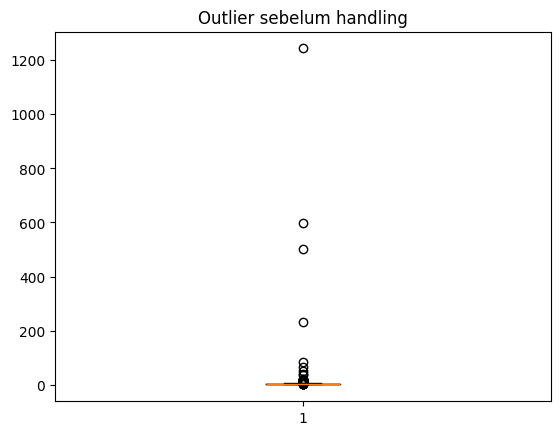

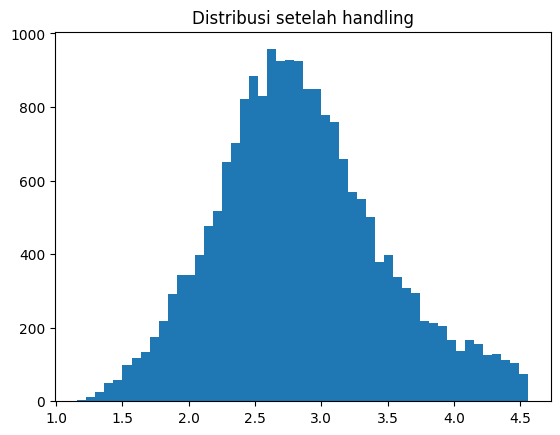

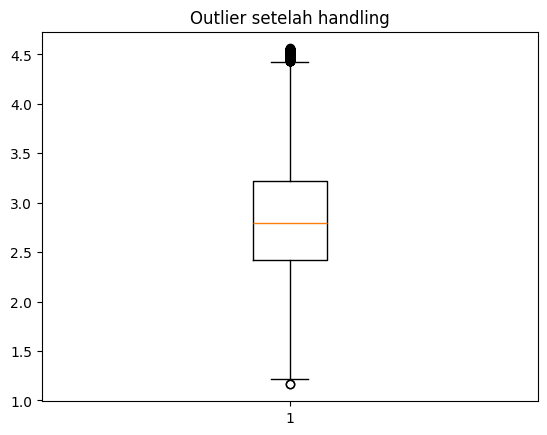

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

# membaca dataset
df = pd.read_csv("california_dataset.csv")

# kolom yang dipilih
kolom = "AveOccup"

# distribusi sebelum handling
plt.figure()
plt.hist(df[kolom], bins=50)
plt.title("Distribusi sebelum handling")
plt.show()

plt.figure()
plt.boxplot(df[kolom])
plt.title("Outlier sebelum handling")
plt.show()


# ===== IQR METHOD =====
Q1 = df[kolom].quantile(0.25)
Q3 = df[kolom].quantile(0.75)
IQR = Q3 - Q1

batas_bawah = Q1 - 1.5 * IQR
batas_atas = Q3 + 1.5 * IQR

# filtering data tanpa outlier
df_clean = df[(df[kolom] >= batas_bawah) & (df[kolom] <= batas_atas)]


# distribusi setelah handling
plt.figure()
plt.hist(df_clean[kolom], bins=50)
plt.title("Distribusi setelah handling")
plt.show()

plt.figure()
plt.boxplot(df_clean[kolom])
plt.title("Outlier setelah handling")
plt.show()

65.5 -10.5


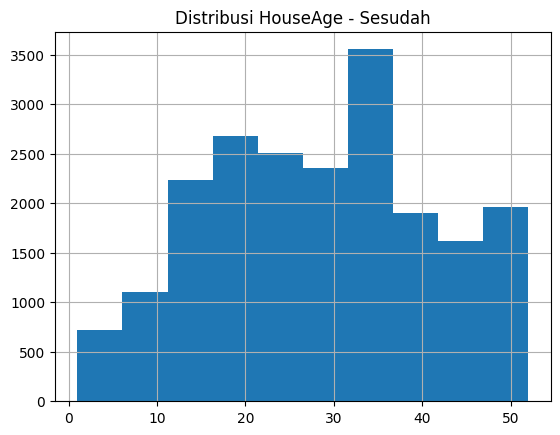

In [6]:
# Melakukan loop untuk mengecek distribusi tiap kolom
import pandas as pd
import matplotlib.pyplot as plt

df_california = pd.read_csv("california_dataset.csv")
def find_outlier_boundary(df, variable):
    IQR = df[variable].quantile(0.75) - df[variable].quantile(0.25)
    lower_boundary = df[variable].quantile(0.25) - (IQR * 1.5)
    upper_boundary = df[variable].quantile(0.75) + (IQR * 1.5)
    return upper_boundary, lower_boundary

HouseAge_upper_limit, HouseAge_lower_limit = find_outlier_boundary(df_california, 'HouseAge')
print(HouseAge_upper_limit, HouseAge_lower_limit)

# === 3. Handle outlier dengan capping ===
df_california['HouseAge'] = df_california['HouseAge'].clip(
    lower=HouseAge_lower_limit,
    upper=HouseAge_upper_limit
)

# === 4. Cek distribusi SESUDAH handling ===
df_california['HouseAge'].hist()
plt.title('Distribusi HouseAge - Sesudah')
plt.show()

# C. Missing Value Handling
Missing Value Merupakan nilai yang hilang di suatu kolom, namun tidak hanya sebatas itu. Untuk nilai yang tidak sesuai tapi muncul didalam suatu kolom tertentu juga bisa dianggap sebagai missing value. Misal tipenya kategorikal tapi isinya ada yang berupa angka dan juga sebaliknya.

In [3]:
import pandas as pd
df_company = pd.read_csv('company.csv')

### Aturan missing value handling :
1. jika tipe datanya itu **numerik** -> handling menggunakan **median** (robust / tahan terhadap outlier)
2. jika tipe datanya itu **kategorik / object / string** -> handling menggunakan **mode / modus**

In [9]:
from sklearn.model_selection import train_test_split
#Splitting terlebih dahulu

#train : test = 80:20 atau 75:25 atau (minimum :70:30 atau maksimum: 90:10) bagi angka yg lain (85:15)

## Assignment 2. Missing Value Handling :
1. Cek persentase missing value pada kolom Headquarters di company.csv, Cek jenis missing valuenya ?
2. apakah di drop atau tidak (gunakan syarat drop kolom jika > 20%)
3. jika tidak maka handling, dan dengan cara apa handling nilainya, median atau modus ?

In [10]:
#Tulis jawaban missing value handling kolom Headquarters disini
import pandas as pd

df = pd.read_csv("company.csv")

# cek jumlah missing
missing = df['Headquarters'].isnull().sum()

# total data
total = len(df)

# persentase
persentase = (missing / total) * 100

print("Jumlah missing value:", missing)
print("Persentase missing value:", persentase, "%")

Jumlah missing value: 0
Persentase missing value: 0.0 %


In [12]:
missing = df['Headquarters'].isnull().sum()
total = len(df)

persentase = (missing / total) * 100
if persentase > 20:
    print("Kolom akan di DROP karena missing > 20%")
    df = df.drop(columns=['Headquarters'])
else:
    print("Kolom tidak di drop, akan dilakukan handling")

Kolom tidak di drop, akan dilakukan handling


In [13]:
import pandas as pd

df = pd.read_csv("company.csv")
mode_value = df['Headquarters'].mode()[0]

df['Headquarters'].fillna(mode_value, inplace=True)

C:\Users\Asus\AppData\Local\Temp\ipykernel_16844\2429445988.py:6: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['Headquarters'].fillna(mode_value, inplace=True)


0                New York, NY
1                 Herndon, VA
2                  Boston, MA
3      Bad Ragaz, Switzerland
4                New York, NY
                ...          
667              Fort Lee, NJ
668                        -1
669                        -1
670           Santa Clara, CA
671           Carle Place, NY
Name: Headquarters, Length: 672, dtype: str

# D. Encoding
Definisi : Mengubah tipe kategorikal menjadi numerikal dengan pendekatan aturan encoding untuk persiapan sebelum dilakukannya machine learning modelling. Teknik Encoding yang umum dipakai :
1. One Hot Encoding (OHE) : Lakukan pada kolom gender
2. Label Encoding / Ordinal Encoding : Lakukan pada kolom Yes dan No, Jika Yes menjadi 1 , Jika No menjadi 0. Sebagai Contohnya di kolom  Partner, Dependents.
3. Mean Encoding : Contract

In [16]:
df_churn = pd.read_csv('TelcoCustomerChurn.csv')
df_churn.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [17]:
#Splitting terlebih dahulu


## Assignment 3.a Label Encoder :
1. Pilih kolom-kolom StreamingMovies, StreamingTV, TechSupport, DeviceProtection, OnlineBackup, OnlineSecurity, MultipleLines
2. Ganti nilai yang tidak sesuai : No internet service menjadi No lalu validasi dengan value_counts
3. Kemudian lakukan label Encoder
4. Notes : gunakan Telco-Customer-Churn.csv

In [18]:
#Tulis jawaban
from sklearn.preprocessing import LabelEncoder

kolom_kolom = ['StreamingMovies', 'StreamingTV', 'TechSupport', 'DeviceProtection', 'OnlineBackup', 'OnlineSecurity', 'MultipleLines']

df_churn[kolom_kolom] = df_churn[kolom_kolom].replace("No internet service", "No")

In [19]:
for koloM in kolom_kolom:
    print(koloM)
    print(df_churn[koloM].value_counts())
    

StreamingMovies
StreamingMovies
No     4311
Yes    2732
Name: count, dtype: int64
StreamingTV
StreamingTV
No     4336
Yes    2707
Name: count, dtype: int64
TechSupport
TechSupport
No     4999
Yes    2044
Name: count, dtype: int64
DeviceProtection
DeviceProtection
No     4621
Yes    2422
Name: count, dtype: int64
OnlineBackup
OnlineBackup
No     4614
Yes    2429
Name: count, dtype: int64
OnlineSecurity
OnlineSecurity
No     5024
Yes    2019
Name: count, dtype: int64
MultipleLines
MultipleLines
No                  3390
Yes                 2971
No phone service     682
Name: count, dtype: int64


In [20]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

for koloM in kolom_kolom:
    df_churn[koloM] = label_encoder.fit_transform(df_churn[koloM])

In [21]:
df_churn[kolom_kolom].head()

,StreamingMovies,StreamingTV,TechSupport,DeviceProtection,OnlineBackup,OnlineSecurity,MultipleLines
0,0,0,0,0,1,0,1
1,0,0,0,1,0,1,0
2,0,0,0,0,1,1,0
3,0,0,1,1,0,1,1
4,0,0,0,0,0,0,0


## Selesai :)